In [19]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
using Revise, Distributions, GLMakie, Dates, DataFrames, DataFramesMeta, CSV
GLMakie.activate!(inline=true)
using TrypColonies
import Serialization as s

  Activating project at `c:\Users\Andreas\Dropbox\phd\Kuhn et. al 2026\trypcolonies\2026-Kuhn-et-al`


## Reconstruct the local data_base from Zenodo data

Use this notebook to rebuild `data_base/df.jls` and `data_base/df.csv` with valid paths on your computer.

### What this notebook does

- Cleans existing `data_base` entries whose paths do not exist on this machine.
- Rebuilds database entries from downloaded Zenodo datasets (using `settings.jls`).
- Marks reconstructed entries as metadata-only (`only_metadata = true`).

### Important note

This reconstruction is sufficient for most metric plots. For colony morphology plots that require raw simulation outputs, you must rerun parameter sweeps.
Use `sweep_parallel.jl` with the provided settings in the settings.csv files for each dataset to regenerate the raw data. Expect high resource usage (CPU, RAM, and storage). Start Julia with as many threads as you have logical CPU cores, and ensure sufficient memory (for default parameters, about 8 GB RAM per thread). Otherwise, simulations may fail or fall back to disk and become extremely slow. A single run with one iteration and 16 parameter steps and default parameters requires roughly 70 GB of storage.

### Workflow overview

1. Load the existing `data_base` and remove rows with missing local paths.
2. Provide the local path where Zenodo datasets were downloaded.
3. Rebuild the database from available datasets (metadata only).
4. (Optional) Rerun sweeps to regenerate full raw data for all plots.

### 1. Load existing database and remove invalid paths

This step loads `data_base/df.jls` if it exists.

- Rows with paths that are not found on this computer are deleted.
- If no database exists, a new empty `DataFrame` is created.
- Keep a backup copy of your original `data_base` if needed.

In [20]:
try 
    global data_base = s.deserialize("data_base/df.jls")
    jj = 1
    while jj <= nrow(data_base)
        data_used = DataFrame(data_base[jj,:])
        if false ∈ isdir(data_used.path)
            data_base = deleteat!(data_base,[jj]);
            println("deleted row ", jj, " from data_base, path not found")
            
        else
            jj += 1
        end
    end   

catch 
    println("no existing database found, creating new one")
    global data_base = DataFrame()
end


no existing database found, creating new one


0×0 DataFrame

### 2. Set your custom Zenodo data path  --- INSERT YOUR OWN PATH!!!

Enter the folder that contains the downloaded dataset directories.

- Use the same custom path in other notebooks that call `find_data_path(...)`.
- On Windows, include escaped backslashes (`\\`) in Julia strings.

In [21]:
data_path = find_data_path(custom_path = "C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\")

"C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\"

### Discover available datasets

Read all dataset folders from the selected data path before reconstruction.

In [22]:
data_sets = readdir(data_path)

45-element Vector{String}:
 "Diff_coe_increase_bigger_diamond&circle_gradient_grid_250000_time_seed_7265"
 "Diff_coe_increase_diamond&circle_gradient_grid_250000_time_seed_7872"
 "Diff_coe_lower_250000_time_seed_2551"
 "Diff_coe_lower_250000_time_seed_4971"
 "Diff_coe_small_diamond&circle_gradient_grid_250000_time_seed_0562"
 "Grid_strength_250000_time_seed_0778"
 "Noise_correct_growth_rate_250000_time_seed_0941"
 "Turning_rate_higher_low_noise_01_250000_time_seed_8436"
 "Turning_rate_higher_low_noise_03_250000_time_seed_6081"
 "Turning_rate_low_noise_01_250000_time_seed_8594"
 ⋮
 "radius_collision_random_movemen" ⋯ 62 bytes ⋯ "ng_16_32_250000_time_seed_2774"
 "radius_collision_random_movemen" ⋯ 50 bytes ⋯ "ng_16_32_250000_time_seed_2541"
 "radius_collision_random_movemen" ⋯ 42 bytes ⋯ "ng_16_32_250000_time_seed_1762"
 "radius_collision_random_movemen" ⋯ 37 bytes ⋯ "ing_16_32_250000_time_seed_1626"
 "radius_tanget_sweep_threading_16_32_250000_time_seed_3543"
 "std_dev_test3_default_par

### Rebuild database entries from local datasets

For each dataset folder:

- Load `settings.jls`.
- Add path and runtime metadata.
- Compute missing growth or doubling values when needed.
- Append the result to `data_base` with `only_metadata = true`.

After this step, save the reconstructed `data_base` to disk (`df.jls` and optionally `df.csv`).

In [23]:
for i in 1:length(data_sets)
    data_set = data_sets[i]
    path_data_set = joinpath(data_path, data_set)
    println("data set $i: ", data_set)
    settings = s.deserialize(joinpath(path_data_set, "settings.jls"))
    settings2 = deepcopy(settings)
    settings2["path"] = path_data_set
    settings2["date"] = unix2datetime(time())
    settings2["unix_date"] = time() 
    settings2["run_time"] = 72000
    settings2["storage"] = foldersize(path_data_set)
    settings2["location"] = data_path
    settings2["name"] = data_sets[i][1:end-15]
    settings2["Og_size"] = 502625
    if haskey(settings2, "growth_rate")
        settings2["doubling_time"] = 1/(log2(settings2["growth_rate"]+1))/3600
    elseif haskey(settings2, "doubling_time")
        settings2["growth_rate"] = 2^(1/settings2["doubling_time"]) -1
    end
    settings2["sweep_para_start_value"] = settings2[settings2["sweep_parameter"]]
    settings2["only_metadata"] = true   
    push!(data_base, settings2, promote = true, cols = :union )
end

data set 1: Diff_coe_increase_bigger_diamond&circle_gradient_grid_250000_time_seed_7265
data set 2: Diff_coe_increase_diamond&circle_gradient_grid_250000_time_seed_7872
data set 3: Diff_coe_lower_250000_time_seed_2551
data set 4: Diff_coe_lower_250000_time_seed_4971
data set 5: Diff_coe_small_diamond&circle_gradient_grid_250000_time_seed_0562
data set 6: Grid_strength_250000_time_seed_0778
data set 7: Noise_correct_growth_rate_250000_time_seed_0941
data set 8: Turning_rate_higher_low_noise_01_250000_time_seed_8436
data set 9: Turning_rate_higher_low_noise_03_250000_time_seed_6081
data set 10: Turning_rate_low_noise_01_250000_time_seed_8594
data set 11: Turning_rate_low_noise_03_250000_time_seed_0641
data set 12: adsorption_rate_mixture_diamond&circle_1_0_250000_time_seed_7835
data set 13: adsorption_right_noise_very_hard_walls_sweep_threading_16_32_250000_time_seed_3435
data set 14: alignment_factor_mixture_diamond&circle_gradient_grid_small_bigger_decay_16_16_32_250000_time_seed_9243


In [24]:
first(data_base, 5)

Row,radius_tanget,scale_fac,Og_size,agent_number,noise_dis,velo_var_relative,sweep_parameter,sampling_interval,L,path,walker_step_size,unix_date,run_time,location,name,doubling_time,N,parameter_increment,Diff_coe,adsorption_rate,storage,only_metadata,noise_strength,grid_recover_rate,iterations,growth_rate,Diameter_colony,parameter_steps,velocity_dis,radius_collision,date,sweep_para_start_value,walker_speed_phy,decay_rate,grid_strength,total_time,Δt_walker_min
,Int64,Int64,Int64,Int64,UnionAll,Float64,String,Int64,Tuple…,String,Int64,Float64,Int64,String,String,Float64,Tuple…,Float64,Float64,Float64,Float64,Bool,Float64,Float64,Int64,Float64,Float64,Int64,UnionAll,Int64,DateTime,Float64,Float64,Float64,Int64,Float64,Float64?
1,15,4,502625,250000,Normal,1.5,Diff_coe,1200,"(0.015, 0.015)",C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\Diff_coe_increase_bigger_diamond&circle_gradient_grid_250000_time_seed_7265,3,1.78542e9,72000,C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\,Diff_coe_increase_bigger_diamond&circle_gradient_grid_250000,9.0,"(1000, 1000)",1.0e-9,1.0e-9,1.0e-5,0.0610965,true,0.2,6.66667,1,2.13937e-5,0.003,16,Normal,16,2026-07-30T14:39:58.990,1.0e-9,5.0e-6,0.001,8000,37000.0,0.1
2,15,4,502625,250000,Normal,1.5,Diff_coe,1200,"(0.015, 0.015)",C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\Diff_coe_increase_diamond&circle_gradient_grid_250000_time_seed_7872,3,1.78542e9,72000,C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\,Diff_coe_increase_diamond&circle_gradient_grid_250000,9.0,"(1000, 1000)",1.0e-10,7.0e-11,1.0e-5,0.0897318,true,0.2,6.66667,1,2.13937e-5,0.003,16,Normal,16,2026-07-30T14:39:58.997,7.0e-11,5.0e-6,0.001,8000,36000.0,0.1
3,15,4,502625,250000,Normal,1.5,Diff_coe,1200,"(0.015, 0.015)",C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\Diff_coe_lower_250000_time_seed_2551,3,1.78542e9,72000,C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\,Diff_coe_lower_250000,9.0,"(1000, 1000)",5.0e-12,1.0e-12,1.0e-5,0.0558082,true,0.2,6.66667,1,2.13937e-5,0.003,8,Normal,16,2026-07-30T14:39:58.999,1.0e-12,5.0e-6,0.001,8000,37000.0,0.1
4,15,4,502625,250000,Normal,1.5,Δt_walker_min,1200,"(0.015, 0.015)",C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\Diff_coe_lower_250000_time_seed_4971,3,1.78542e9,72000,C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\,Diff_coe_lower_250000,9.0,"(1000, 1000)",0.005,7.0e-11,1.0e-5,0.0111628,true,0.2,6.66667,1,2.13937e-5,0.003,5,Normal,16,2026-07-30T14:39:59.002,0.0,5.0e-6,0.001,8000,37000.0,0.0
5,15,4,502625,250000,Normal,1.5,Diff_coe,1200,"(0.015, 0.015)",C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\Diff_coe_small_diamond&circle_gradient_grid_250000_time_seed_0562,3,1.78542e9,72000,C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\,Diff_coe_small_diamond&circle_gradient_grid_250000,9.0,"(1000, 1000)",1.0e-10,7.0e-9,1.0e-5,0.0352553,true,0.2,6.66667,1,2.13937e-5,0.003,16,Normal,16,2026-07-30T14:39:59.002,7.0e-9,5.0e-6,0.001,8000,36000.0,0.1


In [34]:
data_used = DataFrame(data_base[29,:])

Row,radius_tanget,scale_fac,Og_size,agent_number,noise_dis,velo_var_relative,sweep_parameter,sampling_interval,L,path,walker_step_size,unix_date,run_time,location,name,doubling_time,N,parameter_increment,Diff_coe,adsorption_rate,storage,only_metadata,noise_strength,grid_recover_rate,iterations,growth_rate,Diameter_colony,parameter_steps,velocity_dis,radius_collision,date,sweep_para_start_value,walker_speed_phy,decay_rate,grid_strength,total_time,Δt_walker_min
,Int64,Int64,Int64,Int64,UnionAll,Float64,String,Int64,Tuple…,String,Int64,Float64,Int64,String,String,Float64,Tuple…,Float64,Float64,Float64,Float64,Bool,Float64,Float64,Int64,Float64,Float64,Int64,UnionAll,Int64,DateTime,Float64,Float64,Float64,Int64,Float64,Float64?
1,15,4,502625,250000,Normal,1.5,noise_strength,1200,"(0.015, 0.015)",C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\noise_strength_mixture_diamond&circle_gradient_grid_small_bigger_decay_16_16_32_250000_time_seed_6413,3,1.78542e9,72000,C:\\Users\\Andreas\\Desktop\\simulation_data_intermediate\\,noise_strength_mixture_diamond&circle_gradient_grid_small_bigger_decay_16_16_32_250000,16.5,"(1000, 1000)",0.05,7.0e-11,1.0e-5,0.0334864,true,0.05,6.66667,1,1.16692e-5,0.003,16,Normal,16,2026-07-30T14:39:59.054,0.05,5.0e-6,0.001,8000,36000.0,missing


### Build a summary plot across parameter steps

Create a multi-metric summary plot using selected parameter indices in `para_range`.

- `para_range` controls which parameter steps are shown.
- `data_r` maps each selected step to the corresponding dataset index.
- If you plot only one dataset, `data_r` can stay constant.
- If you combine multiple datasets, ensure `para_range` and `data_r` have matching lengths.

This section compares trajectories for area growth, cell count, adsorption, and morphology metrics in one figure.

### Plot configuration and interpretation notes

Before running the plotting cells, verify these settings:

- `s_p`: name of the sweep parameter used in the legend labels.
- `it_u`: iterations per parameter step (used to locate metric files).
- `Og_size`: reference area for cell-density normalization.
- `para_range`: subset of parameter steps to visualize (for example every second step).

Output overview:

- Row 1: growth and density-related metrics vs time.
- Row 2: morphology metrics (`W`, `CV`, `MaxP1`, `I_k`) vs time.
- Row 3: the same morphology metrics vs relative area increase.

For `CV` and `MaxP1`, early points are skipped (`[3:end]`) to reduce discretization artifacts at the beginning of simulations.

In [36]:
s_p = data_used.sweep_parameter[1]
it_u = data_used.iterations[1]  
plt_n = 3
Og_size = data_used[!,"Og_size"][1]
metric_path_vec = create_metric_path_vector(data_used.path);

In [37]:
it_u = data_used.iterations[1]  
plt_n = 3

para_range = Int[]
data_r = Int[]
# plot every second parameter increment 
for i in  1:length(metric_path_vec)
    for j in 1:2:data_used.parameter_steps[i]
        push!(para_range, j)
        push!(data_r, i)
    end
end

println(data_r)
println(para_range)

[1, 1, 1, 1, 1, 1, 1, 1]
[1, 3, 5, 7, 9, 11, 13, 15]


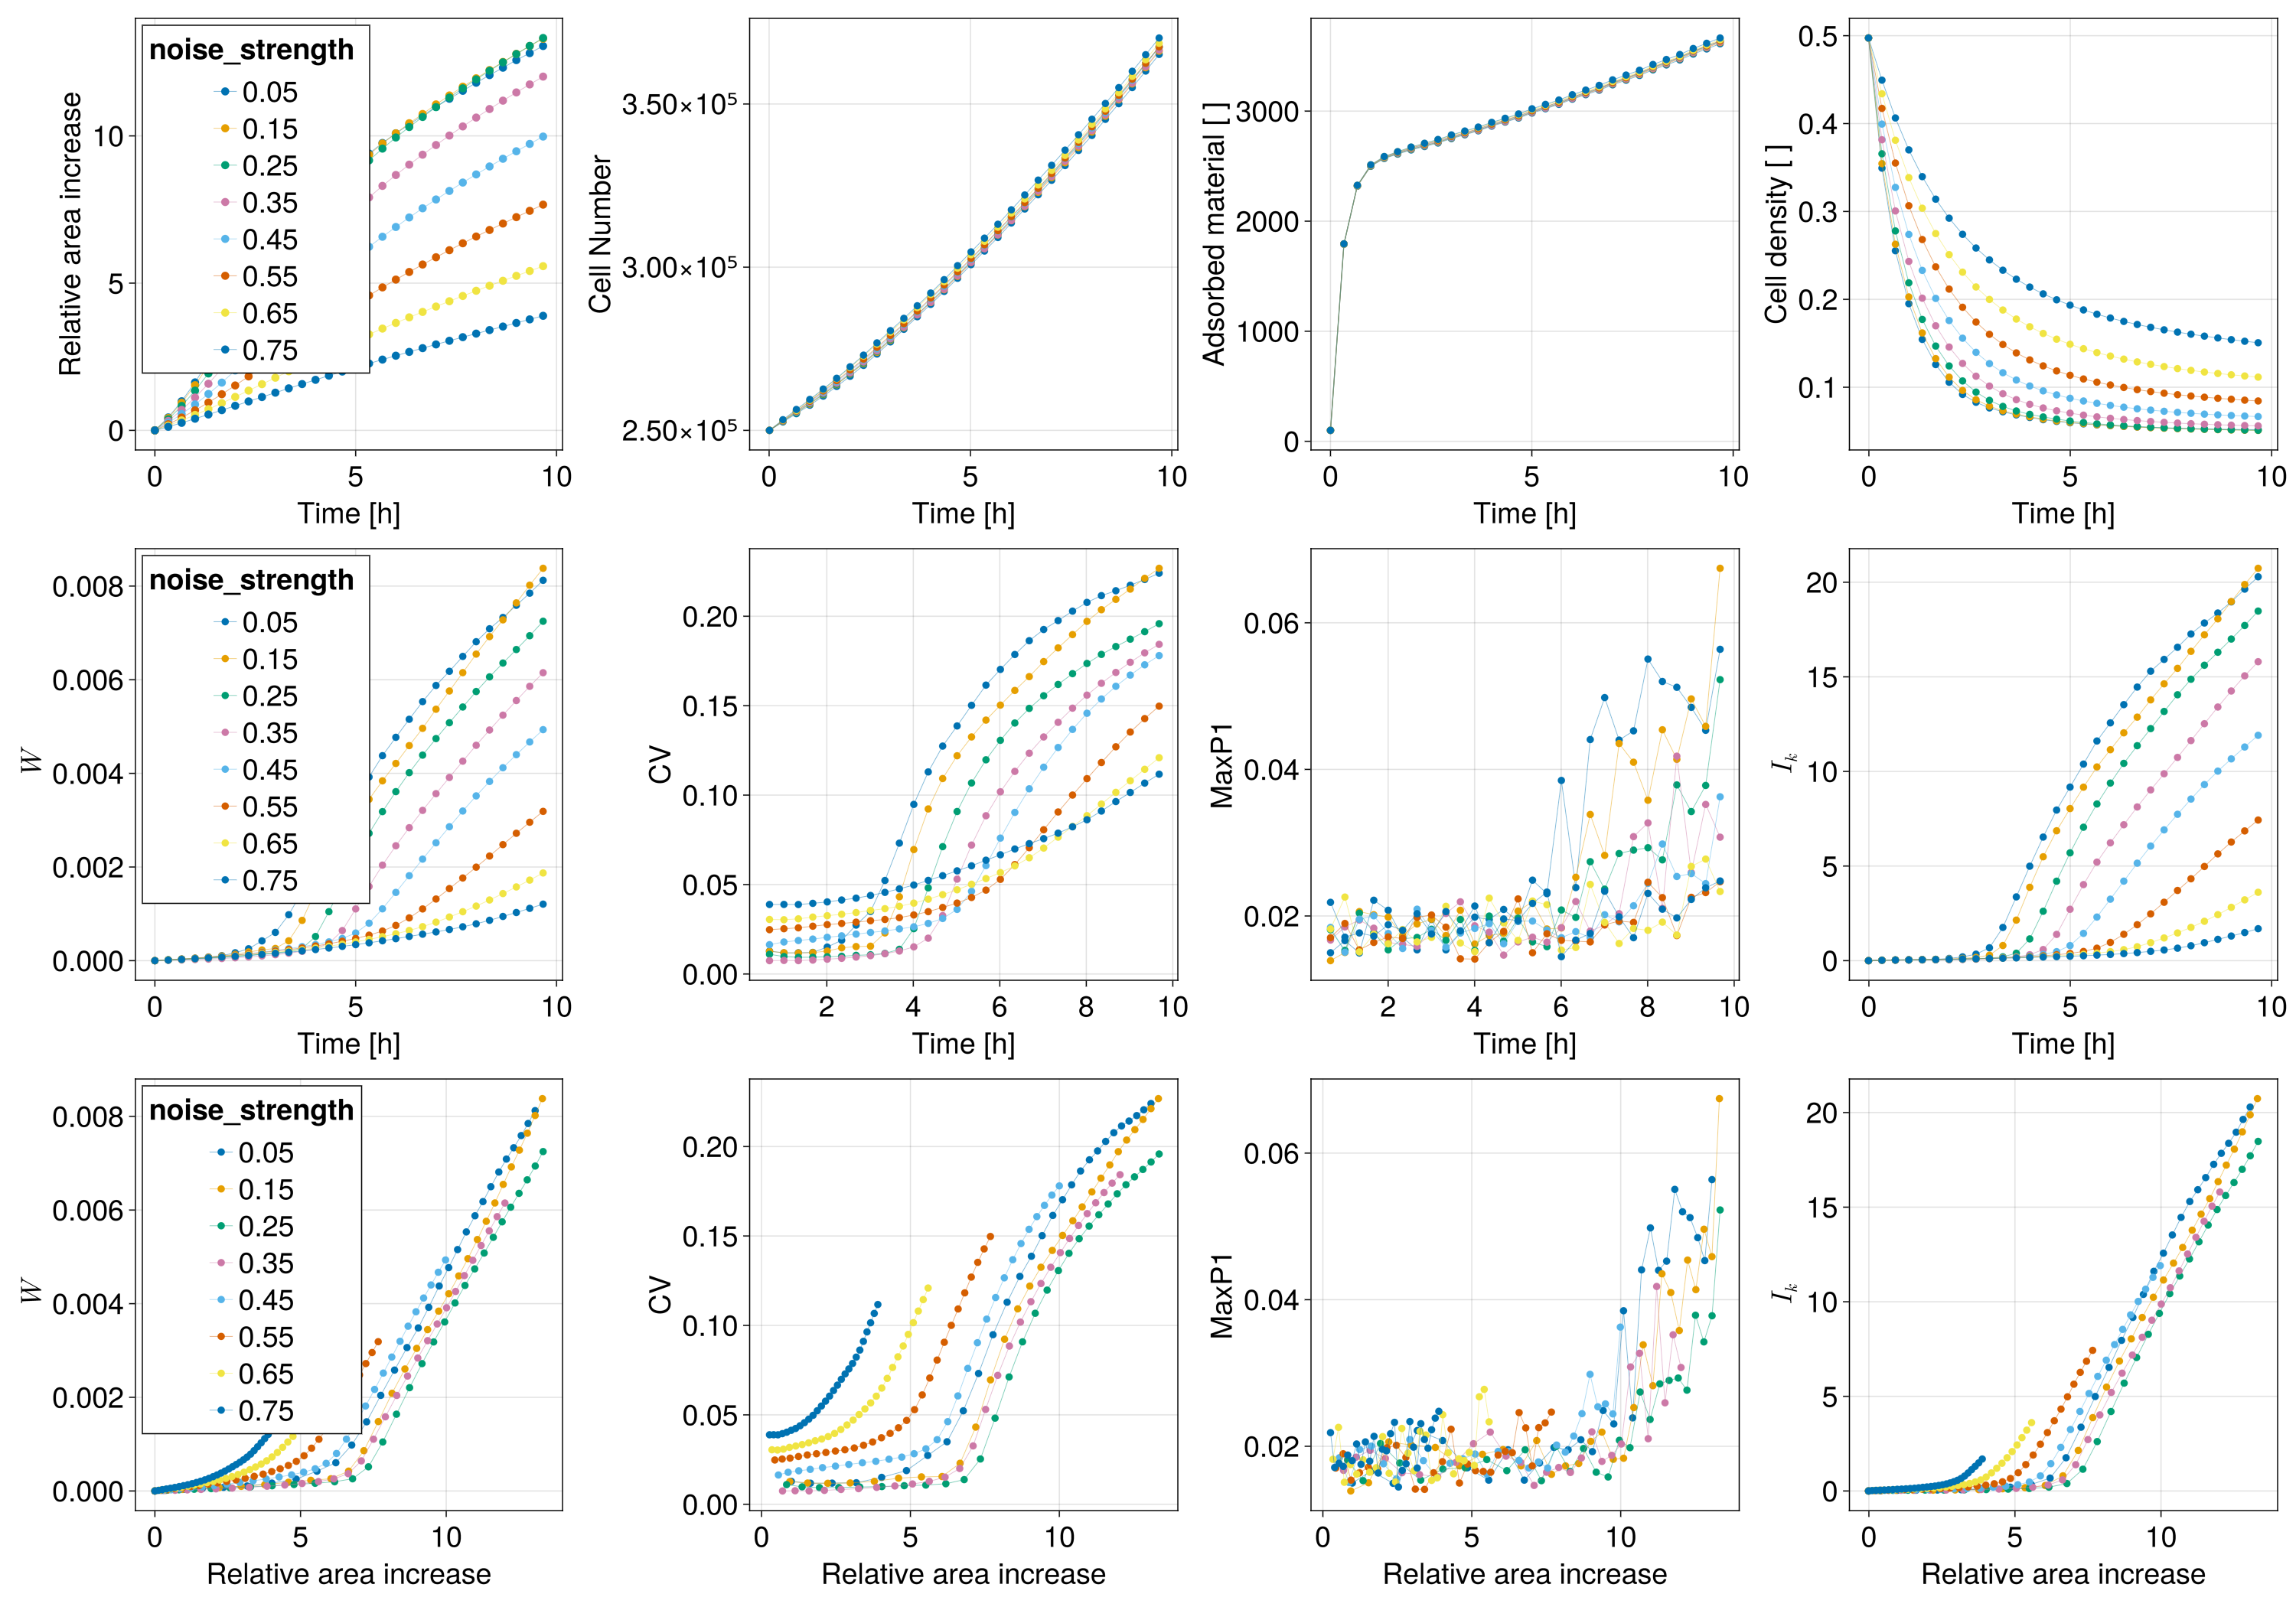

GLMakie.Screen(...)

In [38]:
Para_name = "$(s_p)"

update_theme!(Theme(fontsize = 25))


size = (2000, 1400)
fig6 = Figure(size = size)
ax = Axis(fig6[1,1], ylabel = "Relative area increase", xlabel = "Time [h]")
ax1 = Axis(fig6[1,2], ylabel = "Cell Number", xlabel = "Time [h]")
ax1_1 = Axis(fig6[1,3], ylabel = "Adsorbed material [ ]", xlabel = "Time [h]")
ax1_2 = Axis(fig6[1,4], ylabel = "Cell density [ ]", xlabel = "Time [h]")

ax2 = Axis(fig6[2,1], ylabel = L"W", xlabel = "Time [h]")
ax3 = Axis(fig6[2,2], ylabel = "CV", xlabel = "Time [h]")
ax4 = Axis(fig6[2,3], ylabel = "MaxP1", xlabel = "Time [h]")
ax5 = Axis(fig6[2,4], ylabel = L"I_k", xlabel = "Time [h]")


ax6 = Axis(fig6[3,1], ylabel = L"W", xlabel = "Relative area increase")
ax7 = Axis(fig6[3,2], ylabel = "CV", xlabel = "Relative area increase")
ax8 = Axis(fig6[3,3], ylabel = "MaxP1", xlabel = "Relative area increase")
ax9 = Axis(fig6[3,4], ylabel = L"I_k", xlabel = "Relative area increase")


for (i,p) in enumerate(para_range)
    metric_dict = s.deserialize(metric_path_vec[data_r[i]][p*it_u])
    label_s = "$(round(data_used.parameter_increment[data_r[i]]*(p-1)+data_used[!,s_p][data_r[i]], sigdigits =3))"
    # normalize by area 
    
    scatterlines!(ax, metric_dict[:time], metric_dict[:area_gain], linewidth = .3, label= label_s,markersize  = 10) 
    scatterlines!(ax1, metric_dict[:time], metric_dict[:cell_gain], linewidth = .3, label= label_s)
    scatterlines!(ax1_1, metric_dict[:time], metric_dict[:adsorb], linewidth = .3, label= label_s)
    scatterlines!(ax1_2, metric_dict[:time], metric_dict[:cell_gain]./((metric_dict[:area_gain].+1)*Og_size), linewidth = .3, label= label_s)


    scatterlines!(ax2, metric_dict[:time],metric_dict[:W], linewidth = .3, label= label_s) 
    


    # the [3:end] slicing for CV and MaxP1 is to avoid the initial time points where the metric do not have much meaning due to due discretization artefacts, which would lead to undefined or very large values for CV and MaxP1.
    #By starting from the 3rd time point, we ensure that we are calculating these metrics on more stable data where the mean is likely to be greater than zero.
    scatterlines!(ax3, metric_dict[:time][3:end], metric_dict[:cv][3:end], linewidth = .3, label= label_s) 
    scatterlines!(ax4, metric_dict[:time][3:end], metric_dict[:max_p1][3:end], linewidth = .3, label= label_s) 

   
    scatterlines!(ax5, metric_dict[:time], metric_dict[:fk], linewidth = .3, label= label_s) 


    scatterlines!(ax6, metric_dict[:area_gain],metric_dict[:W], linewidth = .3, label= label_s)
    
        
    
    scatterlines!(ax7, metric_dict[:area_gain][3:end], metric_dict[:cv][3:end], linewidth = .3, label= label_s)
   
    scatterlines!(ax8, metric_dict[:area_gain][3:end], metric_dict[:max_p1][3:end], linewidth = .3, label= label_s)
    scatterlines!(ax9, metric_dict[:area_gain], metric_dict[:fk], linewidth = .3, label= label_s)
end


#axislegend(ax,"$(Para_name),η = $(data_used.noise_strength[1]) ", position = :lt)
axislegend(ax, "$(Para_name) ", position = :lt)
axislegend(ax2, "$(Para_name) ", position = :lt)
axislegend(ax6, "$(Para_name)", position = :lt)


#save(data_used.path[1]*"\\analysis\\roughness_all.png", fig6, size = size)
display(fig6)

### Save newly constructed Database inside Data_base folder


In [ ]:
s.serialize("data_base/df.jls", data_base)
CSV.write("data_base/df.csv", data_base)